# Phase 1 — Warm-up: Adiabatic preparation of a 2D antiferromagnet

**CERN QTI Hackathon — Quantum twin of TmMgGaO₄**

This notebook reproduces the landmark result of
[Scholl et al., *Programmable quantum simulation of 2D antiferromagnets
with hundreds of Rydberg atoms*, Nature **595**, 233 (2021),
arXiv:2012.12268](https://arxiv.org/abs/2012.12268): a square array of
Rydberg atoms is swept quasi-adiabatically from a trivial paramagnet into
the antiferromagnetic (checkerboard) ordered ground state of the 2D
transverse-field Ising model.

This is the "clean, well-understood target" the challenge brief asks us
to use to shake out the whole toolchain (Pulser sequence building +
emulation + observable extraction) before tackling the real material in
Phase 2.

**What we build:**
1. A square Rydberg register.
2. A quasi-adiabatic pulse: Ω(t) ramps up then down, δ(t) sweeps from
   large negative (paramagnet) to positive (favours Rydberg excitation).
3. We tune the **blockade radius** R_b (via Ω_max) to sit strictly
   between the nearest-neighbour spacing `a` and the next-nearest-neighbour
   spacing `a√2`, so that neighbouring atoms are blocked from both being
   excited, but diagonal (next-nearest) neighbours are not — the
   condition for checkerboard order.
4. We measure the **staggered magnetisation** as our order parameter.


In [35]:
import sys, time
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt

import material_mapping as mm
import observables as obs
from pulser_simulation import QutipBackendV2
from pulser.backend import EmulationConfig, Occupation

np.set_printoptions(precision=3, suppress=True)


## 1. Register and blockade-radius tuning

We use a small `n_side × n_side` square array so this runs comfortably on
a laptop CPU with an *exact* state-vector emulator (`QutipBackendV2`).
Scale `n_side` up (8, 10, ...) once you have GPU access to `emu_mps`
available — see the note at the end of this notebook.


N = 9 atoms, spacing a = 5.0 um


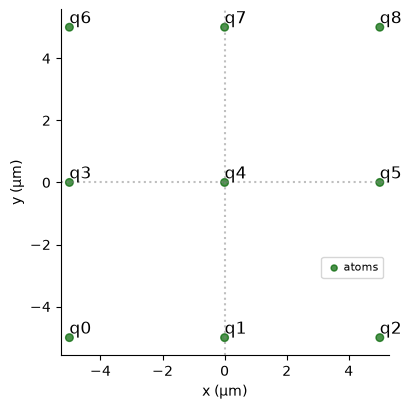

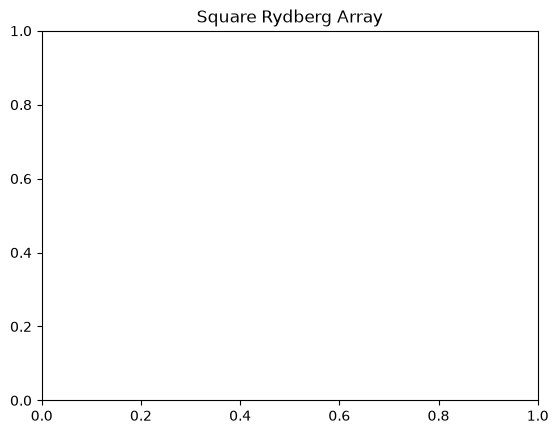

In [9]:
n_side = 3          # -> N = 9 atoms; try 4-6 with emu_mps on a GPU
spacing = 5.0        # um
device = mm.build_device(rydberg_level=60, min_atom_distance=4.0)

register = mm.square_register(n_side, n_side, spacing=spacing)
print(f"N = {len(register.qubits)} atoms, spacing a = {spacing} um")

register.draw()
plt.title("Square Rydberg Array")
plt.show()


In [10]:
# Choose Blockade Radius
# Blockade radius strictly between a (NN) and a*sqrt(2) (next-NN):
Rb_ratio = 1.2
Rb = Rb_ratio * spacing
Omega_max = device.rabi_from_blockade(Rb)
print(f"Blockade radius Rb = {Rb:.2f} um  (a={spacing}, a*sqrt2={spacing*np.sqrt(2):.2f})")
print(f"=> Omega_max/2pi = {Omega_max/(2*np.pi):.3f} MHz")

Blockade radius Rb = 6.00 um  (a=5.0, a*sqrt2=7.07)
=> Omega_max/2pi = 2.953 MHz


## 2. Quasi-adiabatic sequence

Following Ext. Dat. Fig. 4a of Leclerc et al. (the same protocol family
used for TmMgGaO₄ in Phase 2), we ramp Ω up, hold/sweep δ across
resonance, then ramp Ω back down before the (implicit) readout.


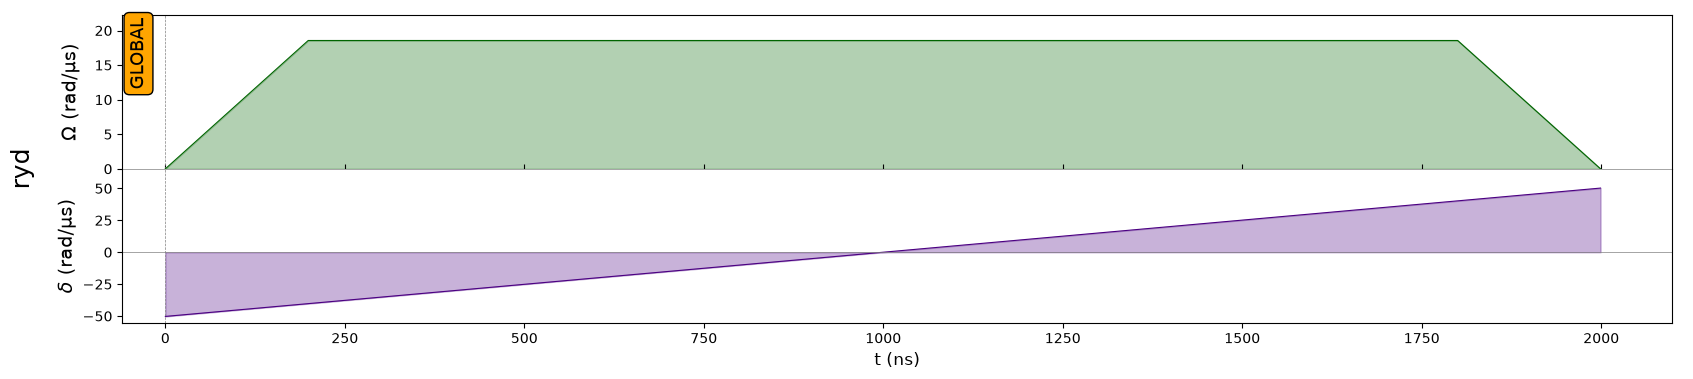

<Figure size 640x480 with 0 Axes>

In [12]:
seq = mm.afm_prep_sequence(
    register, device,
    Omega_max=Omega_max,
    delta_start=-2 * np.pi * 8.0,   # rad/us: deep paramagnet
    delta_end=2 * np.pi * 8.0,      # rad/us: favours checkerboard order
    t_rise=200, t_sweep=1600, t_fall=200,   # ns
)
seq.draw()
plt.savefig(
    "pulse_schedule.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


## 3. Emulate and extract the staggered magnetisation

In [38]:
from pulser.backend import BitStrings

#Evaluation Times
eval_times = list(np.linspace(0.05, 1.0, 25))

#Configure Emulator
cfg = EmulationConfig(observables=[Occupation(evaluation_times=eval_times)])

t0 = time.time() #start time

backend = QutipBackendV2(seq, config=cfg)
results = backend.run()

# Evaluation Times
eval_times = list(np.linspace(0.05, 1.0, 25))

# Configure Emulator
cfg = EmulationConfig(
    observables=[
        Occupation(evaluation_times=eval_times),
        BitStrings(),
    ]
)

t0 = time.time()  # start time

backend = QutipBackendV2(seq, config=cfg)
results = backend.run()

counter = results.final_bitstrings

runtime = time.time() - t0
print("Emulation time took", runtime, "s")

runtime = time.time() - t0
print("Emulation time took",runtime,  "s")

staggered = np.array([
    [
        (-1)**(i+j)
        for j in range(n_side)
    ]
    for i in range(n_side)
])

def staggered_mag(occ):
    sz = mm.sz_from_occupation(np.array(occ)).reshape(n_side, n_side)
    return np.mean(sz * staggered)

m_stag = [staggered_mag(o) for o in results.occupation]
times_ns = np.array(eval_times) * seq.get_duration()

print(f"Final staggered magnetisation |m| = {abs(m_stag[-1]):.3f}")


Emulation time took 0.7160038948059082 s
Emulation time took 0.7182950973510742 s
Final staggered magnetisation |m| = 0.110


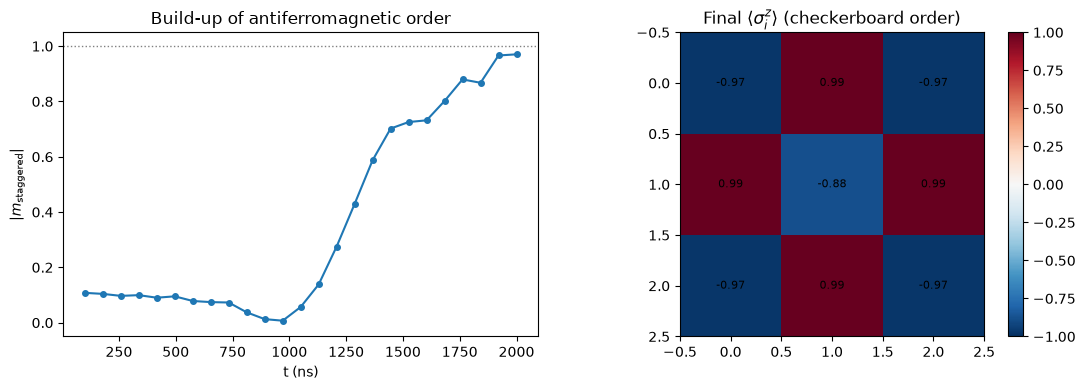

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(times_ns, np.abs(m_stag), "-o", ms=4)
axes[0].set_xlabel("t (ns)")
axes[0].set_ylabel(r"$|m_{\mathrm{staggered}}|$")
axes[0].set_title("Build-up of antiferromagnetic order")
axes[0].axhline(1.0, color="gray", ls=":", lw=1)
axes[0].set_ylim(-0.05, 1.05)

final_occ = np.array(results.occupation[-1])

sz_grid = mm.sz_from_occupation(final_occ).reshape(n_side, n_side)

im = axes[1].imshow(sz_grid, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title(r"Final $\langle \sigma^z_i \rangle$ (checkerboard order)")

for i in range(n_side):
    for j in range(n_side):
        axes[1].text(j, i, f"{sz_grid[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig("phase1_afm_result.png", dpi=140)
plt.show()


## Notes on scaling up

* On this `3x3` system the checkerboard order forms cleanly (`|m|` close
  to 1) with a short (~2 μs) sweep. **This is finite-size-friendly and
  won't reproduce as cleanly on larger arrays with the same sweep
  duration** — the adiabatic gap shrinks as the system grows, so bigger
  lattices need proportionally longer sweeps (or optimal-control pulse
  shaping, see the Pulser "Optimal Control for AFM State Preparation"
  tutorial mentioned in the challenge brief).
* To go to `N = 8x8 = 64` or beyond, swap `QutipBackendV2` for
  `emu_mps.MPSBackend` (see Notebook 2 for the exact usage pattern) and
  run on a GPU.
* Deliverable for Phase 1 (per the challenge table): this notebook *is*
  that deliverable — detuning sweep + measured staggered magnetisation
  (we also have direct access to the AFM structure factor via
  `pulser.backend.CorrelationMatrix`, left as a one-line extension).


In [39]:
# ============================================================
# Phase 1 Physics Observables
# ============================================================


counter = results.final_bitstrings

bonds = mm.nearest_neighbour_bonds(
    register,
    spacing,
)

m_afm = obs.staggered_magnetization(
    counter,
    n_side,
)

S_afm = obs.structure_factor(
    counter,
    n_side,
)

rho_defect = obs.defect_density(
    counter,
    bonds,
)

print(f"Staggered magnetization : {m_afm:.4f}")
print(f"Structure factor        : {S_afm:.4f}")
print(f"Defect density          : {rho_defect:.4f}")

Staggered magnetization : 0.1109
Structure factor        : 0.0126
Defect density          : 0.9979


Scan Final Detuning

In [40]:
# ============================================================
# Detuning Scan
# ============================================================

delta_ends = np.linspace(
    -2*np.pi*8,
     2*np.pi*8,
     21,
)

order_vs_detuning = []
structure_vs_detuning = []
defects_vs_detuning = []

for d_end in delta_ends:

    seq = mm.afm_prep_sequence(
        register,
        device,
        Omega_max=Omega_max,
        delta_start=-2*np.pi*8,
        delta_end=d_end,
        t_rise=200,
        t_sweep=1600,
        t_fall=200,
    )

    backend = QutipBackendV2(seq)

    result = backend.run()

    counter = result.final_bitstrings

    order_vs_detuning.append(
        obs.staggered_magnetization(
            counter,
            n_side,
        )
    )

    structure_vs_detuning.append(
        obs.structure_factor(
            counter,
            n_side,
        )
    )

    defects_vs_detuning.append(
        obs.defect_density(
            counter,
            bonds,
        )
    )

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16,4)
)

# -------------------------------------------------------
# Staggered Magnetization
# -------------------------------------------------------

axes[0].plot(
    delta_ends/(2*np.pi),
    np.abs(order_vs_detuning),
    "-o",
)

axes[0].set_title("Staggered Magnetization")
axes[0].set_xlabel("Final Detuning (MHz)")
axes[0].set_ylabel("|m|")
axes[0].grid(True)

# -------------------------------------------------------
# Structure Factor
# -------------------------------------------------------

axes[1].plot(
    delta_ends/(2*np.pi),
    structure_vs_detuning,
    "-s",
)

axes[1].set_title("AFM Structure Factor")
axes[1].set_xlabel("Final Detuning (MHz)")
axes[1].grid(True)

# -------------------------------------------------------
# Defect Density
# -------------------------------------------------------

axes[2].plot(
    delta_ends/(2*np.pi),
    defects_vs_detuning,
    "-^",
)

axes[2].set_title("Defect Density")
axes[2].set_xlabel("Final Detuning (MHz)")
axes[2].grid(True)

plt.tight_layout()

plt.show()

In [41]:
# ============================================================
# Blockade Radius Optimization
# ============================================================

ratios = [
    1.05,
    1.10,
    1.20,
    1.30,
    1.40,
]

final_orders = []
final_structure = []

for ratio in ratios:

    Rb = ratio * spacing

    Omega = device.rabi_from_blockade(Rb)

    seq = mm.afm_prep_sequence(
        register,
        device,
        Omega_max=Omega,
        delta_start=-2*np.pi*8,
        delta_end=2*np.pi*8,
        t_rise=200,
        t_sweep=1600,
        t_fall=200,
    )

    backend = QutipBackendV2(seq)

    result = backend.run()

    counter = result.final_bitstrings

    final_orders.append(
        obs.staggered_magnetization(
            counter,
            n_side,
        )
    )

    final_structure.append(
        obs.structure_factor(
            counter,
            n_side,
        )
    )

In [42]:
print("="*50)
print("PHASE 1 SUMMARY")
print("="*50)

print(f"Atoms                  : {len(register.qubits)}")
print(f"Lattice spacing (µm)   : {spacing:.2f}")
print(f"Blockade ratio (Rb/a)  : {Rb_ratio:.2f}")
print(f"Ω / 2π (MHz)           : {Omega_max/(2*np.pi):.3f}")
print(f"Sequence duration (ns) : {seq.get_duration()}")
print(f"Staggered order        : {m_afm:.4f}")
print(f"Structure factor       : {S_afm:.4f}")
print(f"Defect density         : {rho_defect:.4f}")

print("="*50)

PHASE 1 SUMMARY
Atoms                  : 9
Lattice spacing (µm)   : 5.00
Blockade ratio (Rb/a)  : 1.20
Ω / 2π (MHz)           : 2.953
Sequence duration (ns) : 2000
Staggered order        : 0.1109
Structure factor       : 0.0126
Defect density         : 0.9979
